In [1]:
# MU-Glioma-Post data

import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Setup paths
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"

# 2. Load Clinical Data
clinical_data = pd.ExcelFile(clinical_data_path)
for sheet in clinical_data.sheet_names:
    df = pd.read_excel(clinical_data_path, sheet_name=sheet)
    print(f"Sheet: {sheet} | Entries: {len(df)} | Columns: {df.columns.tolist()}")


Sheet: Data Dictionary | Entries: 184 | Columns: ['Data Collection Name', 'Data Descriptor /Metadata Name']
Sheet: MU Glioma Post | Entries: 203 | Columns: ['Patient ID', 'Sex at Birth', 'Race', 'Age at diagnosis', 'Primary Diagnosis', 'Grade of Primary Brain Tumor', 'Stereotactic Biopsy before Surgical Resection', 'Progression', 'Time to First Progression (Days)', 'Type of 1st Progression', 'Second Progression/Recurrence', 'Type of 2nd Progression', 'Multiple surgeries', 'Hospice', 'Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)', 'IDH1 mutation', 'IDH2 mutation', '1p/19q', 'ATRX mutation', 'MGMT methylation', 'BRAF V600E mutation', 'TERT promoter mutation', 'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation', 'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion', 'TP53 alteration', 'Other mutations/alterations', 'Previous Brain Tumor', 'Type of previous brain tumor', 'Year of previous surgery', 'Grade of Previous brain tumor', 'Number of days 

In [ ]:
# 3. Get Patient IDs from Image Data Directory
image_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post"

patient_ids = [d for d in os.listdir(image_data_path) 
               if os.path.isdir(os.path.join(image_data_path, d)) and not d.startswith('.')]
patient_ids.sort()

# 4. Iterate through each Patient for timepoint and image verification
for pid in patient_ids:
    patient_folder_path = os.path.join(image_data_path, pid)
    
    # Get Timepoint folders
    timepoints = sorted([t for t in os.listdir(patient_folder_path) 
                        if os.path.isdir(os.path.join(patient_folder_path, t)) and not t.startswith('.')])
    
    print(f"\n" + "="*100)
    print(f"Patient ID: {pid} | Timepoints: {timepoints}")
    print("="*100)

    for timepoint in timepoints:
        timepoint_folder_path = os.path.join(patient_folder_path, timepoint)
        
        # Get all .nii.gz files in the folder
        image_files = sorted([f for f in os.listdir(timepoint_folder_path) 
                              if f.endswith('.nii.gz') and not f.startswith('.')])
        
        if not image_files:
            print(f"   ⚠️ No images found in {timepoint}")
            continue

        # Create a grid to show every image found in the folder
        num_images = len(image_files)
        fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
        if num_images == 1: axes = [axes] # Handle single image case
        
        fig.suptitle(f"Patient: {pid}", fontsize=14)

        for i, f_name in enumerate(image_files):
            file_path = os.path.join(timepoint_folder_path, f_name)
            img = nib.load(file_path)
            data = img.get_fdata()
            
            # Show the middle slice (standard for raw data inspection)
            slice_idx = data.shape[2] // 2
            
            axes[i].imshow(np.rot90(data[:, :, slice_idx]), cmap='gray')
            axes[i].set_title(f_name.split('.')[0], fontsize=10)
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()

In [8]:
# Segmentation volumes are in a separate Excel file, so we will load that next and filter for the patients we have images for.

# 1. PATHS
segmentation_volume_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"

# 3. LOAD SEGMENTATION VOLUMES (All Sheets)
segmentation_volumes = pd.ExcelFile(segmentation_volume_path)
volume_data = {}

for sheet in segmentation_volumes.sheet_names:
    # Read the sheet and clean column names
    df = pd.read_excel(segmentation_volume_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    # Standardize column name to Patient_ID
    if 'Patient ID' in df.columns:
        df = df.rename(columns={'Patient ID': 'Patient_ID'})
        
        # 1. GENERATE TIMEPOINT LABELS
        # Since the ID repeats, cumcount() assigns 0 to the 1st occurrence, 1 to the 2nd, etc.
        # We add 1 and convert to "Timepoint_X" to match your image folder names.
        df['Timepoint_Index'] = df.groupby('Patient_ID').cumcount() + 1
        df['Timepoint'] = "Timepoint_" + df['Timepoint_Index'].astype(str)
        
        # 2. Filter for only the patients found in your image folder (patient_ids list)
        df_filtered = df[df['Patient_ID'].isin(patient_ids)].copy()
        
        # 3. Store in the dictionary
        # We keep Patient_ID as the index, but Timepoint is now an explicit column
        volume_data[sheet] = df_filtered.set_index('Patient_ID')
        
        print(f"{sheet}: Found {len(df_filtered)} total scans for {df_filtered['Patient_ID'].nunique()} unique patients.")

Necrotic Tumor Core (Label1): Found 272 total scans for 119 unique patients.
Tumor Infiltration and Edema: Found 419 total scans for 145 unique patients.
Enhancing Tumor Core (Label3): Found 408 total scans for 144 unique patients.
Resection Cavity (Label4): Found 368 total scans for 135 unique patients.


In [10]:
# Patient objects will be built in the next step, where we will map these volumes to the corresponding timepoints and images for each patient.
import os
import nibabel as nib
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 1. Paths
seg_vol_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"
image_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post"
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"

# 2. Extract Patient IDs from Image Data (Filter for Directories Only)
patient_ids = sorted([d for d in os.listdir(image_path) 
                     if os.path.isdir(os.path.join(image_path, d)) and not d.startswith('.')])

# 3. Load Segmentation Volumes, Voxels, and Intensity Measures to Map Patients by Sequence Order
print("📊 Extracting volumes, voxels and T1 Contrast, T1 Native, T2 FLAIR T2 Weighted as ordered sequences")
volume_sequences = {}
voxel_sequences = {}
t1c_mean = {}
t1c_stdevs = {}
t1n_mean = {}
t1n_stdevs = {}
t2f_mean = {}
t2f_stdevs = {}
t2w_mean = {}
t2w_stdevs = {}

seg_file = pd.ExcelFile(seg_vol_path)
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        # Standardize naming
        df = df.rename(columns={'Patient ID': 'Patient_ID'})
        
        # Extract Clean ID (remove suffixes like -Post-treatment_3), and this allows us to group all rows belonging to the same person
        df['Patient_ID_Clean'] = df['Patient_ID'].str.split('-').str[0]
        
        # Identify numerical columns
        voxel_column = 'Number Of Voxels' if 'Number Of Voxels' in df.columns else df.columns[3]
        volume_column = 'Volume (mm^3)' if 'Volume (mm^3)' in df.columns else df.columns[4]
        t1c_mean_column = 'T1 Contrast' if 'T1 Contrast' in df.columns else df.columns[5]
        t1c_stdevs_column = 'T1 Contrast StdDev' if 'T1 Contrast StdDev' in df.columns else df.columns[6]
        t1n_mean_column = 'T1 Native' if 'T1 Native' in df.columns else df.columns[7]
        t1n_stdevs_column = 'T1 Native StdDev' if 'T1 Native StdDev' in df.columns else df.columns[8]
        t2f_mean_column = 'T2 FLAIR' if 'T2 FLAIR' in df.columns else df.columns[9]
        t2f_stdevs_column = 'T2 FLAIR StdDev' if 'T2 FLAIR StdDev' in df.columns else df.columns[10]
        t2w_mean_column = 'T2 Weighted' if 'T2 Weighted' in df.columns else df.columns[11]
        t2w_stdevs_column = 'T2 Weighted StdDev' if 'T2 Weighted StdDev' in df.columns else df.columns[12]

        
        label_key = label_map.get(sheet, sheet)
        
        # Store data as a list for each patient to preserve the order of visits
        voxel_sequences[label_key] = df.groupby('Patient_ID_Clean')[voxel_column].apply(list).to_dict()
        volume_sequences[label_key] = df.groupby('Patient_ID_Clean')[volume_column].apply(list).to_dict()
        t1c_mean[label_key] = df.groupby('Patient_ID_Clean')[t1c_mean_column].apply(list).to_dict()
        t1c_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t1c_stdevs_column].apply(list).to_dict()
        t1n_mean[label_key] = df.groupby('Patient_ID_Clean')[t1n_mean_column].apply(list).to_dict()
        t1n_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t1n_stdevs_column].apply(list).to_dict()
        t2f_mean[label_key] = df.groupby('Patient_ID_Clean')[t2f_mean_column].apply(list).to_dict()
        t2f_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t2f_stdevs_column].apply(list).to_dict()
        t2w_mean[label_key] = df.groupby('Patient_ID_Clean')[t2w_mean_column].apply(list).to_dict()
        t2w_stdevs[label_key] = df.groupby('Patient_ID_Clean')[t2w_stdevs_column].apply(list).to_dict()

# Load clinical data to map to patients
clinical_df = pd.read_excel(clinical_data_path, sheet_name='MU Glioma Post')
clinical_df.columns = clinical_df.columns.str.strip()
if 'Patient ID' in clinical_df.columns:
    clinical_df = clinical_df.rename(columns={'Patient ID': 'Patient_ID'})
    clinical_df['Patient_ID_Clean'] = clinical_df['Patient_ID'].str.split('-').str[0]
    clinical_data = clinical_df.set_index('Patient_ID_Clean').to_dict(orient='index')
print(f"✅ Clinical data loaded for {len(clinical_data)} patients.")

📊 Extracting volumes, voxels and T1 Contrast, T1 Native, T2 FLAIR T2 Weighted as ordered sequences
✅ Clinical data loaded for 203 patients.


In [11]:
clinical_data.get("PatientID_0007")

{'Patient_ID': 'PatientID_0007',
 'Sex at Birth': 'Male',
 'Race': 'White',
 'Age at diagnosis': 79,
 'Primary Diagnosis': 'GBM',
 'Grade of Primary Brain Tumor': 4,
 'Stereotactic Biopsy before Surgical Resection': 0,
 'Progression': 0,
 'Time to First Progression (Days)': nan,
 'Type of 1st Progression': 0,
 'Second Progression/Recurrence': 0,
 'Type of 2nd Progression': 0,
 'Multiple surgeries': 0,
 'Hospice': 0,
 'Overall Survival (Death)': 1,
 'Number of days from Diagnosis to death (Days)': 968.0,
 'IDH1 mutation': 0,
 'IDH2 mutation': 0,
 '1p/19q': 0,
 'ATRX mutation': 4,
 'MGMT methylation': 4,
 'BRAF V600E mutation': 2,
 'TERT promoter mutation': 2,
 'Chromosome 7 gain and Chromosome 10 loss': 2,
 'H3-3A mutation': 2,
 'EGFR amplification': 2,
 'PTEN mutation': 0,
 'CDKN2A/B deletion': 0,
 'TP53 alteration': 0,
 'Other mutations/alterations': nan,
 'Previous Brain Tumor': 'No',
 'Type of previous brain tumor': nan,
 'Year of previous surgery': nan,
 'Grade of Previous brain tu

In [12]:
# 4. Construct Unified Patient Objects (SAFE VERSION)
print("🤖 Building integrated Patient objects...")
patient_objects = {}

for pid in patient_ids:
    patient_folder = Path(image_path) / pid
    
    # --- A. CLINICAL DATA INTEGRATION ---
    # Fetch the clean ID to match the clinical dictionary
    clean_id = pid.split('-')[0]
    # Fetch record from the master 'clinical_data' dict created in Step 3
    patient_clinical = clinical_data.get(clean_id, {})

    obj = {
        'Patient_ID': pid,
        'clinical': patient_clinical,
        'timepoints': [],
        'images': {}, 'voxels': {}, 'volumes': {}, 
        't1c_mean': {}, 't1c_stdevs': {},
        't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {},
        't2w_mean': {}, 't2w_stdevs': {},
        'total_volumes': {}, 'total_voxels': {}
    }
    
    if patient_folder.exists():
        tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        obj['timepoints'] = tps
        
        for i, tp in enumerate(tps):
            tp_path = patient_folder / tp
            obj['images'][tp] = [str(f) for f in tp_path.glob("*.nii*")]
            
            # Temporary dicts for this specific scan
            tp_volume, tp_voxel = {}, {}
            tp_t1c_mean, tp_t1c_stdevs = {}, {}
            tp_t1n_mean, tp_t1n_stdevs = {}, {}
            tp_t2f_mean, tp_t2f_stdevs = {}, {}
            tp_t2w_mean, tp_t2w_stdevs = {}, {}

            for label in volume_sequences.keys():
                # Fetch sequences from MASTER dicts using unique local names (Safe)
                # This prevents the AttributeError crash
                volume_seq = volume_sequences.get(label, {}).get(pid, [])
                voxel_seq = voxel_sequences.get(label, {}).get(pid, [])
                t1cm_seq = t1c_mean.get(label, {}).get(pid, [])
                t1cs_seq = t1c_stdevs.get(label, {}).get(pid, []) # <--- Master Dict
                t1nm_seq = t1n_mean.get(label, {}).get(pid, [])
                t1ns_seq = t1n_stdevs.get(label, {}).get(pid, [])
                t2fm_seq = t2f_mean.get(label, {}).get(pid, [])
                t2fs_seq = t2f_stdevs.get(label, {}).get(pid, [])
                t2wm_seq = t2w_mean.get(label, {}).get(pid, [])
                t2ws_seq = t2w_stdevs.get(label, {}).get(pid, [])

                # Safety Check: Does this scan index 'i' exist in all data lists?
                if i < len(volume_seq) and i < len(voxel_seq):
                    tp_volume[label] = float(volume_seq[i])
                    tp_voxel[label] = int(voxel_seq[i])
                    
                    # Safe mapping for intensity features
                    if i < len(t1cm_seq): tp_t1c_mean[label] = float(t1cm_seq[i])
                    if i < len(t1cs_seq): tp_t1c_stdevs[label] = float(t1cs_seq[i])
                    if i < len(t1nm_seq): tp_t1n_mean[label] = float(t1nm_seq[i])
                    if i < len(t1ns_seq): tp_t1n_stdevs[label] = float(t1ns_seq[i])
                    if i < len(t2fm_seq): tp_t2f_mean[label] = float(t2fm_seq[i])
                    if i < len(t2fs_seq): tp_t2f_stdevs[label] = float(t2fs_seq[i])
                    if i < len(t2wm_seq): tp_t2w_mean[label] = float(t2wm_seq[i])
                    if i < len(t2ws_seq): tp_t2w_stdevs[label] = float(t2ws_seq[i])

            # Store computed data
            if tp_voxel:
                obj['volumes'][tp] = tp_volume
                obj['voxels'][tp] = tp_voxel
                obj['t1c_mean'][tp] = tp_t1c_mean
                obj['t1c_stdevs'][tp] = tp_t1c_stdevs
                obj['t1n_mean'][tp] = tp_t1n_mean
                obj['t1n_stdevs'][tp] = tp_t1n_stdevs
                obj['t2f_mean'][tp] = tp_t2f_mean
                obj['t2f_stdevs'][tp] = tp_t2f_stdevs
                obj['t2w_mean'][tp] = tp_t2w_mean
                obj['t2w_stdevs'][tp] = tp_t2w_stdevs
                obj['total_volumes'][tp] = sum(tp_volume.values())
                obj['total_voxels'][tp] = sum(tp_voxel.values())

    patient_objects[pid] = obj

print(f"✅ Patient objects built. PatientID_0007 has clinical data: {'Age' in patient_objects['PatientID_0007']['clinical']}")

🤖 Building integrated Patient objects...
✅ Patient objects built. PatientID_0007 has clinical data: False



🧬 FULL DATA AUDIT: PatientID_0007 | 5 Timepoints

📍 Timepoint number 1: Timepoint_2


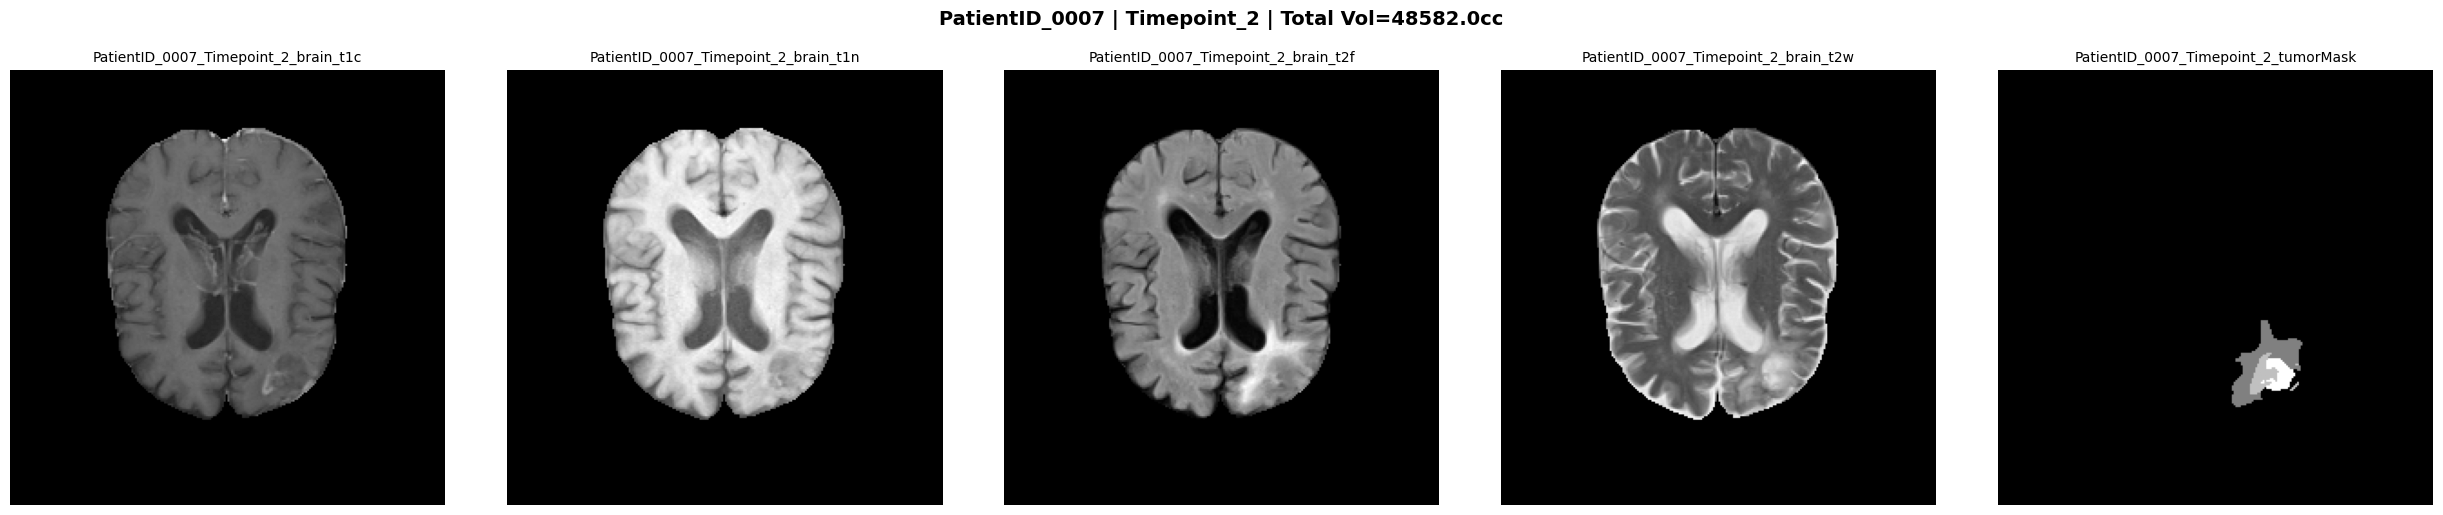

   📊 VOLUMES:
      Necrotic    :      0.0 mm³ (      0 vox)
      Edema       : 27,824.0 mm³ ( 27,824 vox)
      Enhancing   :  7,787.0 mm³ (  7,787 vox)
      Resection   : 12,971.0 mm³ ( 12,971 vox)
      TOTAL       : 48,582.0 mm³ ( 48,582 vox)
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 293.9HU | stdev=  65.0
      T1N   : mean= 206.3HU | stdev=  33.0
      T2F   : mean= 328.7HU | stdev=  59.9
      T2W   : mean= 529.1HU | stdev= 112.5
   🌊 EDEMA INTENSITY (T2-FLAIR):
      T2F_Edema: mean= 405.5HU | stdev=  56.0 | Het= 13.8%
----------------------------------------------------------------------------------------------------
   🏥 CLINICAL DATA SNAPSHOT:
      [Demographics] Age: 79 | Sex: Male | Race: White
      [Molecular]    MGMT: 4 | IDH1: 0 | EGFR: 2 | TERT: 2
      [Diagnosis]    Primary: GBM | Grade: 4 | Progression: 0
      [Temporal]     Days since Diagnosis: 0.0

📍 Timepoint number 2: Timepoint_3


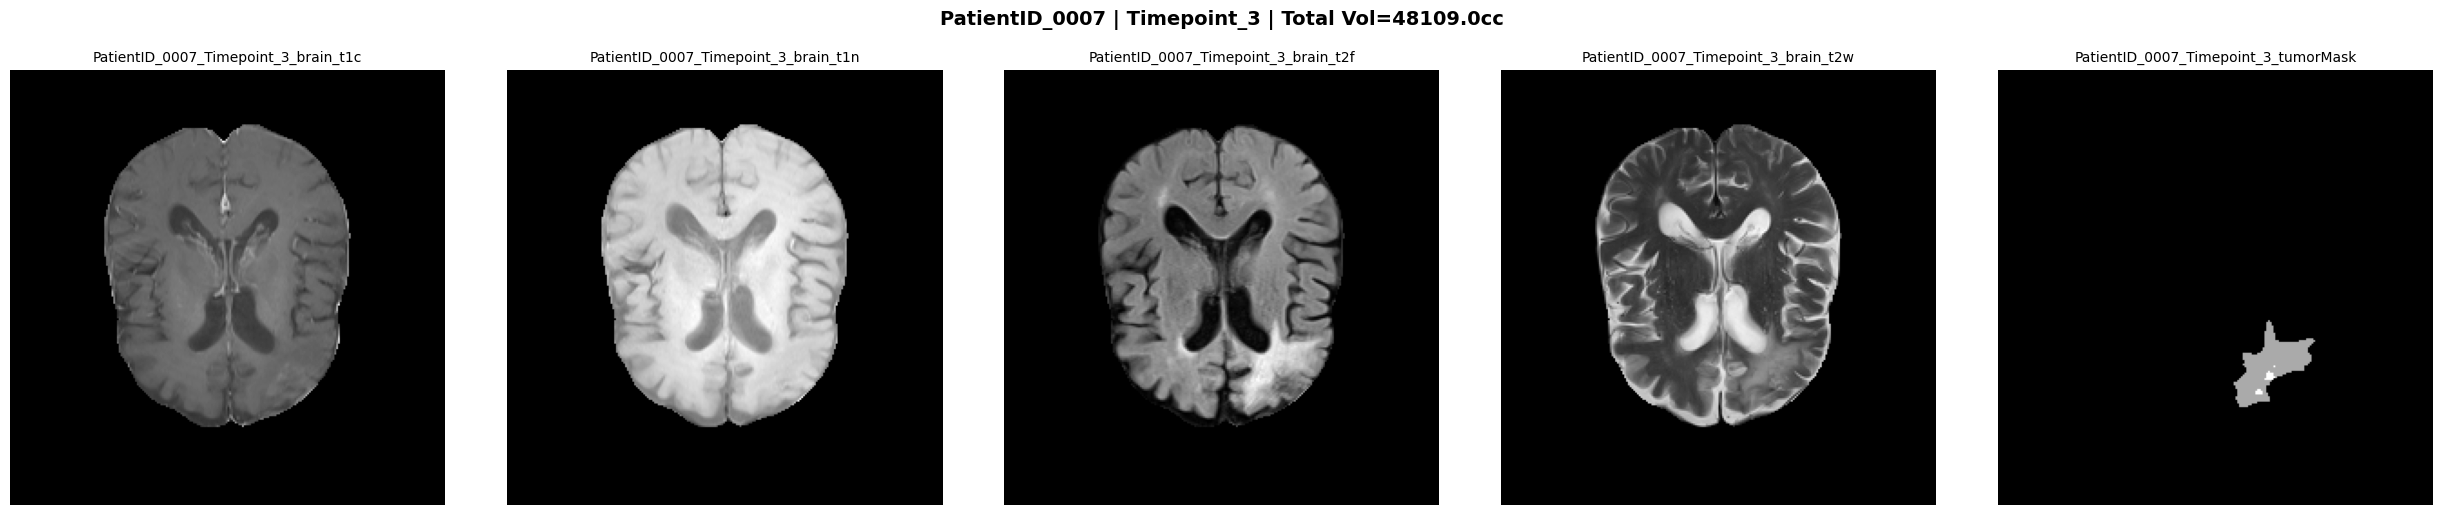

   📊 VOLUMES:
      Necrotic    :      0.0 mm³ (      0 vox)
      Edema       : 33,179.0 mm³ ( 33,179 vox)
      Enhancing   :  5,996.0 mm³ (  5,996 vox)
      Resection   :  8,934.0 mm³ (  8,934 vox)
      TOTAL       : 48,109.0 mm³ ( 48,109 vox)
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 701.0HU | stdev= 125.8
      T1N   : mean= 618.3HU | stdev=  60.8
      T2F   : mean= 402.7HU | stdev=  88.7
      T2W   : mean= 866.1HU | stdev= 253.0
   🌊 EDEMA INTENSITY (T2-FLAIR):
      T2F_Edema: mean= 557.1HU | stdev=  71.3 | Het= 12.8%
----------------------------------------------------------------------------------------------------
   📈 GROWTH vs Timepoint_2:   -1.0%
   🏥 CLINICAL DATA SNAPSHOT:
      [Demographics] Age: 79 | Sex: Male | Race: White
      [Molecular]    MGMT: 4 | IDH1: 0 | EGFR: 2 | TERT: 2
      [Diagnosis]    Primary: GBM | Grade: 4 | Progression: 0
      [Temporal]     Days since Diagnosis: nan

📍 Timepoint number 3: Timepoint_4


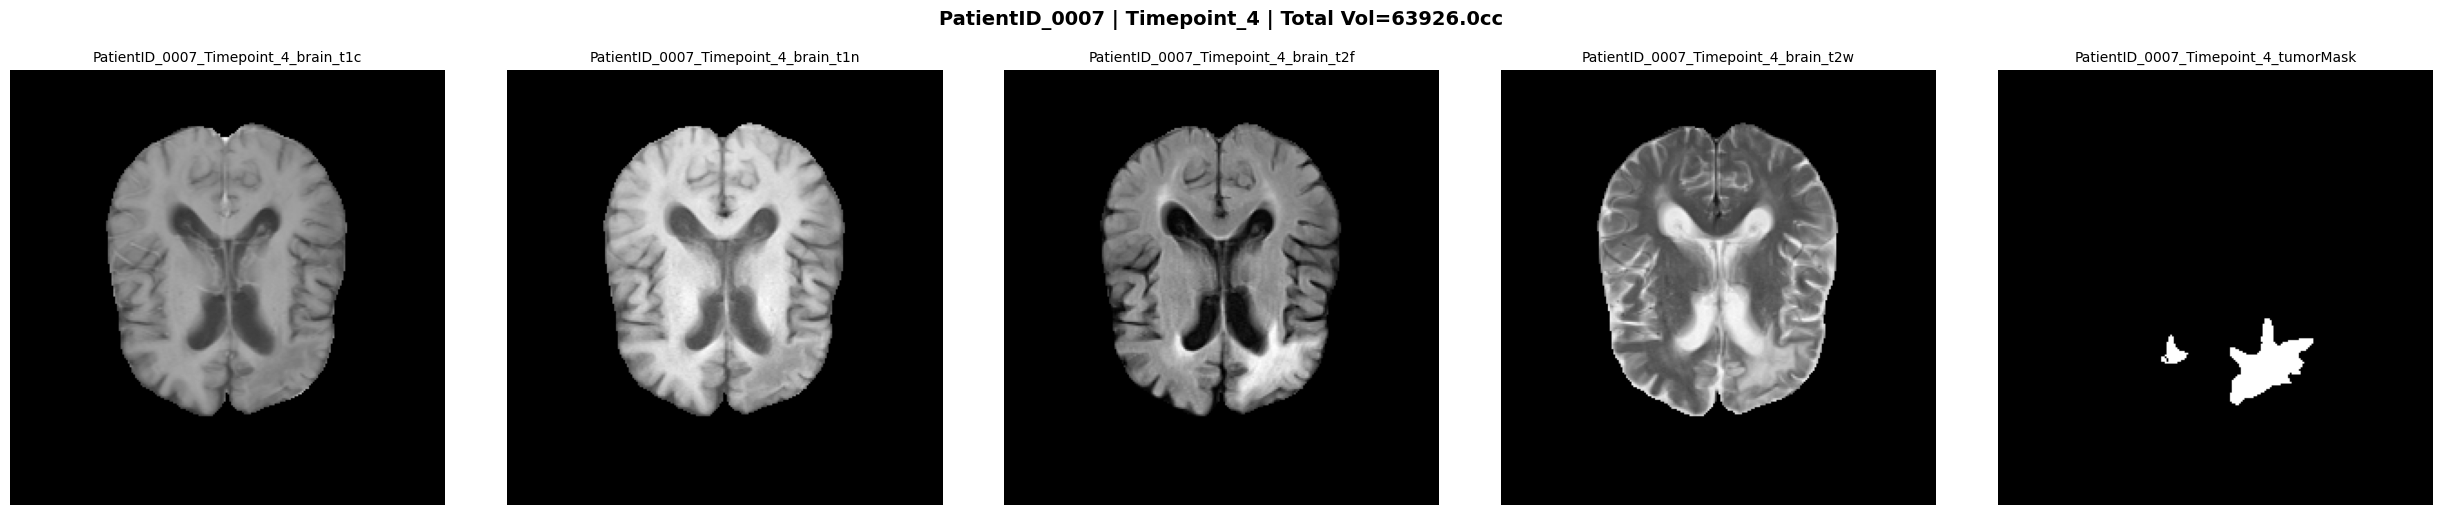

   📊 VOLUMES:
      Necrotic    :      0.0 mm³ (      0 vox)
      Edema       : 54,831.0 mm³ ( 54,831 vox)
      Enhancing   :  3,263.0 mm³ (  3,263 vox)
      Resection   :  5,832.0 mm³ (  5,832 vox)
      TOTAL       : 63,926.0 mm³ ( 63,926 vox)
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 616.0HU | stdev= 108.7
      T1N   : mean= 166.6HU | stdev=  32.3
      T2F   : mean= 243.0HU | stdev=  76.9
      T2W   : mean= 519.9HU | stdev= 102.7
   🌊 EDEMA INTENSITY (T2-FLAIR):
      T2F_Edema: mean= 368.2HU | stdev=  48.5 | Het= 13.2%
----------------------------------------------------------------------------------------------------
   📈 GROWTH vs Timepoint_3:  +32.9%
   🏥 CLINICAL DATA SNAPSHOT:
      [Demographics] Age: 79 | Sex: Male | Race: White
      [Molecular]    MGMT: 4 | IDH1: 0 | EGFR: 2 | TERT: 2
      [Diagnosis]    Primary: GBM | Grade: 4 | Progression: 0
      [Temporal]     Days since Diagnosis: 178.0

📍 Timepoint number 4: Timepoint_5


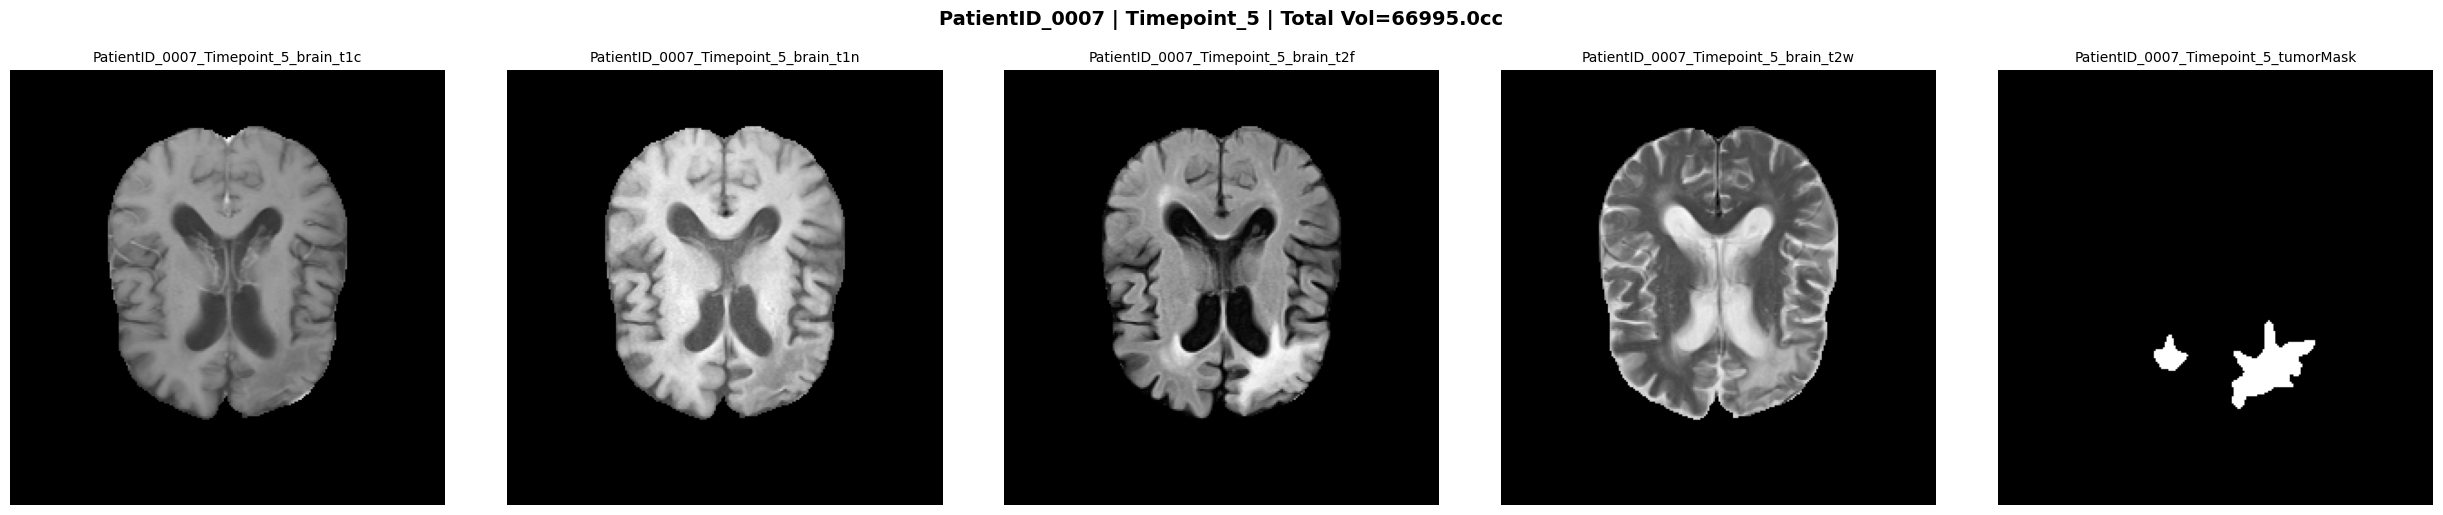

   📊 VOLUMES:
      Necrotic    :      0.0 mm³ (      0 vox)
      Edema       : 59,179.0 mm³ ( 59,179 vox)
      Enhancing   :  4,074.0 mm³ (  4,074 vox)
      Resection   :  3,742.0 mm³ (  3,742 vox)
      TOTAL       : 66,995.0 mm³ ( 66,995 vox)
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 674.7HU | stdev= 142.5
      T1N   : mean= 175.8HU | stdev=  35.3
      T2F   : mean= 253.6HU | stdev=  77.7
      T2W   : mean= 606.4HU | stdev= 127.9
   🌊 EDEMA INTENSITY (T2-FLAIR):
      T2F_Edema: mean= 388.7HU | stdev=  50.6 | Het= 13.0%
----------------------------------------------------------------------------------------------------
   📈 GROWTH vs Timepoint_4:   +4.8%
   🏥 CLINICAL DATA SNAPSHOT:
      [Demographics] Age: 79 | Sex: Male | Race: White
      [Molecular]    MGMT: 4 | IDH1: 0 | EGFR: 2 | TERT: 2
      [Diagnosis]    Primary: GBM | Grade: 4 | Progression: 0
      [Temporal]     Days since Diagnosis: 264.0

📍 Timepoint number 5: Timepoint_6


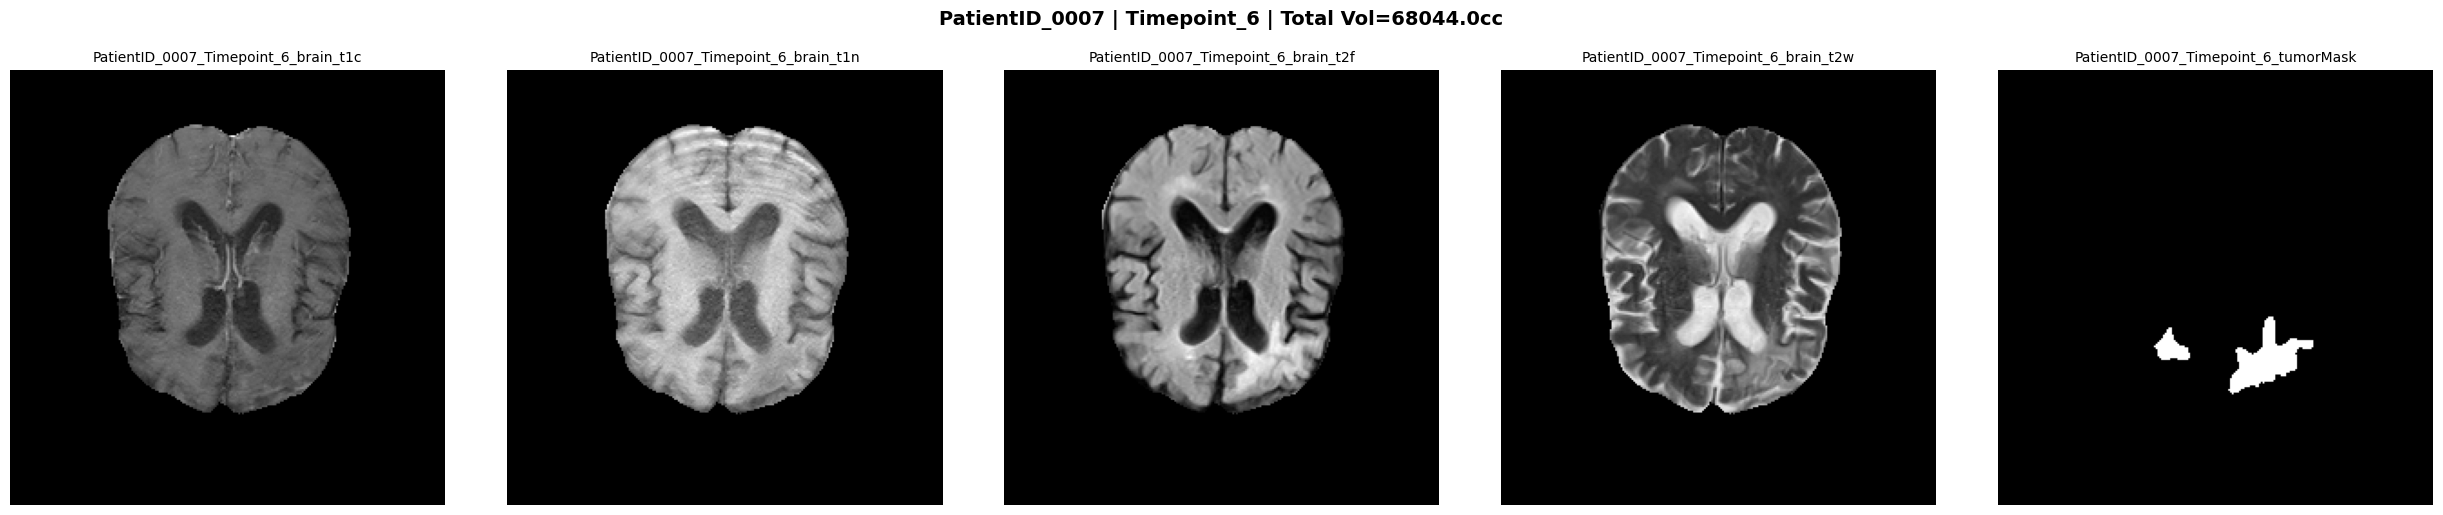

   📊 VOLUMES:
      Necrotic    :      0.0 mm³ (      0 vox)
      Edema       : 61,231.0 mm³ ( 61,231 vox)
      Enhancing   :    641.0 mm³ (    641 vox)
      Resection   :  6,172.0 mm³ (  6,172 vox)
      TOTAL       : 68,044.0 mm³ ( 68,044 vox)
   🔬 RADIOMICS (Enhancing Tumor):
      T1C   : mean= 443.5HU | stdev=  74.0
      T1N   : mean= 251.1HU | stdev=  34.5
      T2F   : mean= 232.0HU | stdev=  54.6
      T2W   : mean= 537.0HU | stdev= 126.2
   🌊 EDEMA INTENSITY (T2-FLAIR):
      T2F_Edema: mean= 329.1HU | stdev=  38.4 | Het= 11.7%
----------------------------------------------------------------------------------------------------
   📈 GROWTH vs Timepoint_5:   +1.6%
   🏥 CLINICAL DATA SNAPSHOT:
      [Demographics] Age: 79 | Sex: Male | Race: White
      [Molecular]    MGMT: 4 | IDH1: 0 | EGFR: 2 | TERT: 2
      [Diagnosis]    Primary: GBM | Grade: 4 | Progression: 0
      [Temporal]     Days since Diagnosis: 366.0

✅ AUDIT COMPLETE: Ready for Phase 6 Bayesian modeling!


In [13]:
# 5. Complete Data Audit: Images + Volumes + Intensity Features
sample_id = "PatientID_0007" 

if sample_id:
    patient = patient_objects[sample_id]
    print(f"\n{'='*120}")
    print(f"🧬 FULL DATA AUDIT: {sample_id} | {len(patient['timepoints'])} Timepoints")
    print(f"{'='*120}")

    for tp_idx, tp in enumerate(patient['timepoints']):
        print(f"\n📍 Timepoint number {tp_idx+1}: {tp}")
        
        # --- A. IMAGE VISUALIZATION (All modalities) ---
        images = sorted(patient['images'].get(tp, []))
        if images:
            num_imgs = min(6, len(images))  # Show up to 6 MRI types
            fig, axes = plt.subplots(1, num_imgs, figsize=(5*num_imgs, 5))
            if num_imgs == 1: axes = [axes]
            
            fig.suptitle(f"{sample_id} | {tp} | Total Vol={patient['total_volumes'][tp]:.1f}cc", 
                        fontsize=14, fontweight='bold', y=1.02)
            
            for i, img_path in enumerate(images[:num_imgs]):
                img_obj = nib.load(img_path)
                data = img_obj.get_fdata()
                mid_slice = data.shape[2] // 2
                axes[i].imshow(np.rot90(data[:, :, mid_slice]), cmap='gray')
                axes[i].set_title(Path(img_path).name.split('.')[0], fontsize=10)
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.show()
        
        # --- B. VOLUMES & VOXELS ---
        voxels = patient['voxels'].get(tp, {})
        volumes = patient['volumes'].get(tp, {})
        t1c_means = patient['t1c_mean'].get(tp, {})
        t1c_stdevs = patient['t1c_stdevs'].get(tp, {})
        t1n_means = patient['t1n_mean'].get(tp, {})
        t1n_stdevs = patient['t1n_stdevs'].get(tp, {})
        t2f_means = patient['t2f_mean'].get(tp, {})
        t2f_stdevs = patient['t2f_stdevs'].get(tp, {})
        t2w_means = patient['t2w_mean'].get(tp, {})
        t2w_stdevs = patient['t2w_stdevs'].get(tp, {})
        total_vol = patient['total_volumes'].get(tp, 0)
        total_vox = sum(voxels.values()) if voxels else 0
        clinical_data = patient['clinical_data'] = clinical_data.get(pid, {})
        
        print(f"   📊 VOLUMES:")
        for label in ['Necrotic', 'Edema', 'Enhancing', 'Resection']:
            volume = volumes.get(label, 0)
            voxel = voxels.get(label, 0)
            print(f"      {label:12}: {volume:>8,.1f} mm³ ({voxel:>7,} vox)")
        
        print(f"      {'TOTAL':12}: {total_vol:>8,.1f} mm³ ({total_vox:>7,} vox)")
        
        # --- C. RADIOMICS INTENSITY FEATURES (All modalities, key labels) ---
        print(f"   🔬 RADIOMICS (Enhancing Tumor):")
        modalities = ['t1c', 't1n', 't2f', 't2w']
        for mod in modalities:
            mean_dict = patient[f'{mod}_mean'].get(tp, {})
            stdev_dict = patient[f'{mod}_stdevs'].get(tp, {})
            
            enhancing_mean = mean_dict.get('Enhancing', 'N/A')
            enhancing_stdev = stdev_dict.get('Enhancing', 'N/A')
            
            if enhancing_mean != 'N/A':
                print(f"      {mod.upper():6}: mean={enhancing_mean:>6.1f}HU | stdev={enhancing_stdev:>6.1f}")
        
        # Edema-specific (infiltration marker)
        print(f"   🌊 EDEMA INTENSITY (T2-FLAIR):")
        t2f_mean_edema = patient['t2f_mean'].get(tp, {}).get('Edema', 'N/A')
        t2f_stdev_edema = patient['t2f_stdevs'].get(tp, {}).get('Edema', 'N/A')
        if t2f_mean_edema != 'N/A':
            heterogeneity = t2f_stdev_edema / t2f_mean_edema * 100
            print(f"      T2F_Edema: mean={t2f_mean_edema:>6.1f}HU | stdev={t2f_stdev_edema:>6.1f} | Het={heterogeneity:>5.1f}%")
        
        print("-" * 100)
        
        # GROWTH TREND (if multiple timepoints)
        if tp_idx > 0:
            prev_vol = patient['total_volumes'][patient['timepoints'][tp_idx-1]]
            growth_rate = (total_vol - prev_vol) / prev_vol * 100
            print(f"   📈 GROWTH vs {patient['timepoints'][tp_idx-1]}: {growth_rate:+6.1f}%")
        
        # --- D. CLINICAL DATA SNAPSHOT ---
        clinical = patient.get('clinical', {})
        
        if clinical:
            print(f"   🏥 CLINICAL DATA SNAPSHOT:")
            
            # 1. Define key categories for the Digital Twin model
            # Format: (Display Label, Column Name in CSV)
            demographics = [
                ('Age', 'Age at diagnosis'),
                ('Sex', 'Sex at Birth'),
                ('Race', 'Race')
            ]
            molecular = [
                ('MGMT', 'MGMT methylation'),
                ('IDH1', 'IDH1 mutation'),
                ('EGFR', 'EGFR amplification'),
                ('TERT', 'TERT promoter mutation')
            ]
            diagnosis = [
                ('Primary', 'Primary Diagnosis'),
                ('Grade', 'Grade of Primary Brain Tumor'),
                ('Progression', 'Progression')
            ]

            # 2. Print formatted categories
            print(f"      [Demographics] ", end="")
            print(" | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in demographics]))
            
            print(f"      [Molecular]    ", end="")
            print(" | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in molecular]))
            
            print(f"      [Diagnosis]    ", end="")
            print(" | ".join([f"{l}: {clinical.get(c, 'N/A')}" for l, c in diagnosis]))
            
            # 3. Special: Check for the start date of this specific timepoint if available
            # Note: Your CSV has columns like 'Number of Days from Diagnosis to 1st MRI (Timepoint_1)'
            tp_num = tp.split('_')[-1] # Extract '1' from 'Timepoint_1'
            day_key = f'Number of Days from Diagnosis to {tp_num}st MRI (Timepoint_{tp_num}) '
            # Note: Handle the 'st', 'nd', 'rd', 'th' suffix logic or use a simple search:
            days_from_diag = next((v for k, v in clinical.items() if f"Timepoint_{tp_num}" in k), "N/A")
            print(f"      [Temporal]     Days since Diagnosis: {days_from_diag}")

        else:
            print(f"   🏥 CLINICAL DATA SNAPSHOT: ⚠️ No clinical record found for this Patient ID.")

else:
    print("❌ No valid patient objects found.")

print("\n✅ AUDIT COMPLETE: Ready for Phase 6 Bayesian modeling!")

In [ ]:
# Now that we have verified the data extraction and mapping, we can proceed to the next steps of modeling and analysis using this structured patient data.
import arviz as az
import pymc as pm

# 6. Create a growth dataset for modeling
print("📈 Extracting growth trajectories...")
growth_data = []

for pid, obj in patient_objects.items():
    times = np.arange(len(obj['timepoints']))  # 0,1,2,... (days assumed)
    total_vols = [obj['total_volumes'].get(tp, np.nan) for tp in obj['timepoints']]
    total_voxs = [obj['voxels'].get(tp, {}).get('Total', np.nan) for tp in obj['timepoints']]
    # Only patients with 2+ timepoints
    if len(times) >= 2:
        growth_data.append({
            'Patient_ID': pid,
            'times': times,
            'volumes': np.array(total_vols) / 1000,  # mm³ → cc
            'voxels': np.array(total_voxs),
            'n_obs': len(times)
        })

print(f"✅ {len(growth_data)} patients with longitudinal data")



📈 Extracting growth trajectories...
✅ 155 patients with longitudinal data


In [ ]:
# 7. Analytical Solution (1D Radial Growth Approximation) / Fisher-KPP Priors (Swanson Lab / Hormuth 2023)
def fisher_kpp_analytical(t, rho, D, K):
    """Approximate solution: V(t) ≈ K * (1 - exp(-ρ t))^2 for early growth"""
    return K * (1 - np.exp(-rho * t))**2

# Bayesian Fit (PyMC) - Optimized Vectorized Model
print("🔬 Bayesian calibration starting...")

# Fix priors to be dictionaries so ** unpacking works
priors = {
    'rho_log': {'mu': -2.2, 'sigma': 0.5},
    'D_log': {'mu': -9.0, 'sigma': 0.8},
    'K_log': {'mu': 8.5, 'sigma': 0.3},
    'sigma_log': {'sigma': 0.5}
}

n_patients = len(growth_data)

with pm.Model() as model:
    # Global hyperparameters
    rho_mu = pm.Normal('rho_mu', **priors['rho_log'])
    rho_sigma = pm.HalfNormal('rho_sigma', 0.3)
    D_mu = pm.Normal('D_mu', **priors['D_log'])
    D_sigma = pm.HalfNormal('D_sigma', 0.5)
    
    # Per-patient parameters (Vectorized for speed)
    rho = pm.Normal('rho', mu=rho_mu, sigma=rho_sigma, shape=n_patients)
    D = pm.Normal('D', mu=D_mu, sigma=D_sigma, shape=n_patients)
    K = pm.Normal('K', **priors['K_log'], shape=n_patients)
    sigma_obs = pm.HalfNormal('sigma_obs', **priors['sigma_log'])
    
    # Likelihood
    for i, data in enumerate(growth_data):
        # We use the i-th index of our parameter vectors
        V_pred = fisher_kpp_analytical(data['times'], rho[i], D[i], K[i])
        pm.Normal(f'obs_{i}', mu=V_pred, sigma=sigma_obs, observed=data['volumes_cc'])
    
    # This creates the 'trace' variable
    trace = pm.sample(1000, tune=1000, target_accept=0.9, random_seed=42)

print("✅ Sampling Complete. 'trace' is now defined.")

🔬 Bayesian calibration starting...


/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/pymc/model/core.py:1317: ImputationWarning: Data in obs_106 contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/pymc/model/core.py:1317: ImputationWarning: Data in obs_109 contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho_mu, rho_sigma, D_mu, D_sigma, rho, D, K, sigma_obs, obs_106_unobserved, obs_109_unobserved]


KeyError: 0

In [ ]:
# 8. Posterior Analysis & Visualization
print("📊 Posterior summaries...")
summary = az.summary(trace, var_names=['rho_', 'D_', 'K_'])
print(summary.head(10))

# Plot fits
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (ax_row, data) in enumerate(zip(axes, growth_data[:6])):
    ax = ax_row[0]
    times = data['times']
    vols_obs = data['volumes_cc']
    
    # Posterior predictive samples
    post_samples = pm.sample_posterior_predictive(trace, model=model, var_names=[f'obs_{i}'])
    V_post = post_samples.posterior_predictive[f'obs_{i}'].values
    
    ax.plot(times, vols_obs, 'ko', ms=8, label='Observed')
    ax.plot(times, V_post.T[:100].T, 'C0', alpha=0.3, label='Posterior')
    ax.set_title(f"{data['Patient_ID']}\nρ={np.exp(trace.posterior[f'rho_{i}'].mean()):.3f}")
    ax.set_xlabel('Timepoint'); ax.set_ylabel('Volume (cc)')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9. Exporting Posteriors for Neural ODE Residuals
posteriors_df = az.summary(trace, var_names=['rho_', 'D_', 'K_'])
posteriors_df.to_csv('phase6_posteriors.csv', index=False)

print("💾 Exported posteriors → phase6_posteriors.csv")
print("✅ PHASE 6 COMPLETE: ρ, D calibrated → Ready for Neural ODE residuals!")

In [10]:
import sys

# 1. THE PATCH: Force-fix the SciPy removal issue manually
import scipy.signal
if not hasattr(scipy.signal, 'gaussian'):
    from scipy.signal.windows import gaussian
    scipy.signal.gaussian = gaussian
    print("✅ SciPy 'gaussian' patch applied.")

# 2. NOW do your imports
import arviz as az
import pymc as pm
import numpy as np

print(f"✅ Success! ArviZ version: {az.__version__}")
print(f"✅ Success! PyMC version: {pm.__version__}")

✅ Success! ArviZ version: 0.17.1
✅ Success! PyMC version: 5.12.0


This code implements a multimodal longitudinal audit that integrates raw 3D NIfTI imaging with segmented volume data to validate the structural and temporal integrity of each patient object before training. It uses a "smart-slicing" algorithm to identify the peak tumor cross-section across multiple MRI sequences (T1c, T2, FLAIR), overlaying physiological masks to verify that the ground-truth segmentations align with the anatomical reality. By extracting critical metadata—such as voxel spacing and matrix dimensions—the script ensures that the spatial grid is physically calibrated for PINN Laplacian calculations and that the temporal labels are properly synchronized for Neural ODE integration.

In [ ]:
# Clinical Data - Load and set index to Patient ID
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"
clinical_reader = pd.ExcelFile(clinical_data_path)

# Load the specific sheet and SET THE INDEX to Patient ID
clin_key = clinical_reader.sheet_names[1] 
clinical_df = pd.read_excel(clinical_data_path, sheet_name=clin_key)
clinical_df.columns = clinical_df.columns.str.strip() 
clinical_df = clinical_df.set_index('Patient ID') 

patient_objects = {}

for pid in patient_ids:
    patient_obj = {
        'Patient_ID': pid,
        'biomarkers': {},         
        'treatment': {},          
        'temporal_alignment': {}, 
        'trajectories': {},       
        'outcomes': {},           
        'timepoints': []
    }
    
    # A. Extract ALL VHT Features from clinical_df
    # FIX: Use clinical_df instead of clinical_data[clin_key]
    if pid in clinical_df.index:
        clin_row = clinical_df.loc[pid]
        
        # Handle cases where a PID might appear twice in the Excel
        if isinstance(clin_row, pd.DataFrame):
            clin_row = clin_row.iloc[0]
        
        # 1. BIOMARKERS (Priors)
        patient_obj['biomarkers'] = {
            'Sex': clin_row.get('Sex at Birth'),
            'Age_at_Diagnosis': clin_row.get('Age at diagnosis'),
            'Primary_Diagnosis': clin_row.get('Primary Diagnosis'),
            'Tumor_Grade': clin_row.get('Grade of Primary Brain Tumor'),
            'IDH1': clin_row.get('IDH1 mutation'),
            'IDH2': clin_row.get('IDH2 mutation'),
            '1p19q': clin_row.get('1p/19q'),
            'MGMT': clin_row.get('MGMT methylation'),
            'ATRX': clin_row.get('ATRX mutation'),
            'TERT': clin_row.get('TERT promoter mutation'),
            'EGFR': clin_row.get('EGFR amplification'),
            'PTEN': clin_row.get('PTEN mutation'),
            'CDKN2A_B': clin_row.get('CDKN2A/B deletion'),
            'TP53': clin_row.get('TP53 alteration')
        }
        
        # 2. TREATMENT (Mechanistic Inputs)
        # Note: Added leading spaces to some keys to match the Excel's hidden formatting
        patient_obj['treatment'] = {
            'First_Surgery_Days': clin_row.get('Number of days from Diagnosis to First surgery or procedure'),
            'Multiple_Surgeries': clin_row.get('Multiple surgeries'),
            'Radiation': clin_row.get('Radiation Therapy'),
            'RT_Start_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy Start date'),
            'RT_End_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy end date'),
            'RT_Dose_Gy': clin_row.get('Dose'),
            'RT_Fractions': clin_row.get('Number of Fractions'),
            'Chemo': clin_row.get('Initial Chemo Therapy'),
            'Chemo_Name': clin_row.get('Name of Initial Chemo Therapy'),
            'Chemo_Start_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date'),
            'Chemo_End_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy end date'),
            'Additional_Therapy': clin_row.get('Additional Therapy')
        }
        
        # 3. TEMPORAL ALIGNMENT (Days from Diagnosis per MRI scan)
        patient_obj['temporal_alignment'] = {
            'Timepoint_1': clin_row.get('Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
            'Timepoint_2': clin_row.get('Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
            'Timepoint_3': clin_row.get('Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
            'Timepoint_4': clin_row.get('Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
            'Timepoint_5': clin_row.get('Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
            'Timepoint_6': clin_row.get('Number of Days from Diagnosis to 6th MRI (Timepoint_6)')
        }

        # 4. OUTCOMES (Validation Data)
        patient_obj['outcomes'] = {
            'Progression': clin_row.get('Progression'),
            'Time_to_Progression': clin_row.get('Time to First Progression (Days)'),
            'OS_Status': clin_row.get('Overall Survival (Death)'),
            'Days_to_Death': clin_row.get('Number of days from Diagnosis to death (Days)'),
            'Hospice': clin_row.get('Hospice')
        }
    
    # B. Map Image structure + timepoints (from folder names)
    patient_folder = Path(image_data_path) / pid
    if patient_folder.exists():
        found_tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        patient_obj['timepoints'] = found_tps
    
    # C. Map Longitudinal Volumes using Generated Timepoints
    for tp in patient_obj['timepoints']:
        tp_volumes = {}
        for sheet_name, df in volume_data.items():
            if pid in df.index:
                patient_rows = df.loc[[pid]] 
                match = patient_rows[patient_rows['Timepoint'] == tp]
                
                if not match.empty:
                    # Capture the volume column dynamically
                    vol_cols = [c for c in match.columns if 'Volume' in c or 'Vol' in c]
                    if vol_cols:
                        tp_volumes[sheet_name] = match.iloc[0][vol_cols[0]]
        
        if tp_volumes:
            # Mechanistic total: Necrotic + Edema + Enhancing (excludes Resection Label 4)
            core_vals = [v for k, v in tp_volumes.items() if 'Label4' not in k and 'Resection' not in k]
            tp_volumes['Total_Tumor_Volume'] = sum(core_vals)
            patient_obj['trajectories'][tp] = tp_volumes

    patient_objects[pid] = patient_obj

print(f"Created {len(patient_objects)} Patient Objects with the full {len(list(patient_obj['biomarkers'].keys()) + list(patient_obj['treatment'].keys()) + list(patient_obj['temporal_alignment'].keys()) + list(patient_obj['outcomes'].keys()) + list(patient_obj['trajectories'].keys()))}-feature VHT mapping.")

Created 203 Patient Objects with the full 37-feature VHT mapping.


In [ ]:
# =============================================================================
# 4. UNIFIED PATIENT OBJECT INTEGRATION (CLINICAL + IMAGES + VOLUMES)
# =============================================================================
patient_objects = {}

for pid in patient_ids:
    # Initialize the structured object
    patient_obj = {
        'Patient_ID': pid,
        'biomarkers': {},         # 🧬 Biological/Molecular Priors
        'treatment': {},          # ⚡ Mechanistic Perturbations
        'temporal_alignment': {}, # ⏱️ Time (t) for Neural ODEs
        'outcomes': {},           # 🎯 Ground Truth / Prediction
        'timepoints': [],        # 📅 Found in Folders
        'image_paths': {},       # 📂 NIfTI File Names
        'trajectories': {}        # 📏 Volumetric States
    }
    
    # --- PART A: INTEGRATE CLINICAL DATA ---
    if pid in clinical_df.index:
        clin_row = clinical_df.loc[pid]
        if isinstance(clin_row, pd.DataFrame):
            clin_row = clin_row.iloc[0]
        
        # 1. BIOMARKERS (Priors)
        patient_obj['biomarkers'] = {
            'Sex': clin_row.get('Sex at Birth'),
            'Age_at_Diagnosis': clin_row.get('Age at diagnosis'),
            'Primary_Diagnosis': clin_row.get('Primary Diagnosis'),
            'Tumor_Grade': clin_row.get('Grade of Primary Brain Tumor'),
            'IDH1': clin_row.get('IDH1 mutation'),
            'IDH2': clin_row.get('IDH2 mutation'),
            '1p19q': clin_row.get('1p/19q'),
            'MGMT': clin_row.get('MGMT methylation'),
            'ATRX': clin_row.get('ATRX mutation'),
            'TERT': clin_row.get('TERT promoter mutation'),
            'EGFR': clin_row.get('EGFR amplification'),
            'PTEN': clin_row.get('PTEN mutation'),
            'CDKN2A_B': clin_row.get('CDKN2A/B deletion'),
            'TP53': clin_row.get('TP53 alteration')
        }
        
        # 2. TREATMENT (Mechanistic Inputs)
        # Note: Added leading spaces to some keys to match the Excel's hidden formatting
        patient_obj['treatment'] = {
            'First_Surgery_Days': clin_row.get('Number of days from Diagnosis to First surgery or procedure'),
            'Multiple_Surgeries': clin_row.get('Multiple surgeries'),
            'Radiation': clin_row.get('Radiation Therapy'),
            'RT_Start_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy Start date'),
            'RT_End_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy end date'),
            'RT_Dose_Gy': clin_row.get('Dose'),
            'RT_Fractions': clin_row.get('Number of Fractions'),
            'Chemo': clin_row.get('Initial Chemo Therapy'),
            'Chemo_Name': clin_row.get('Name of Initial Chemo Therapy'),
            'Chemo_Start_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date'),
            'Chemo_End_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy end date'),
            'Additional_Therapy': clin_row.get('Additional Therapy')
        }
        
        # 3. TEMPORAL ALIGNMENT (Days from Diagnosis per MRI scan)
        patient_obj['temporal_alignment'] = {
            'Timepoint_1': clin_row.get('Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
            'Timepoint_2': clin_row.get('Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
            'Timepoint_3': clin_row.get('Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
            'Timepoint_4': clin_row.get('Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
            'Timepoint_5': clin_row.get('Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
            'Timepoint_6': clin_row.get('Number of Days from Diagnosis to 6th MRI (Timepoint_6)')
        }

        # 4. OUTCOMES (Validation Data)
        patient_obj['outcomes'] = {
            'Progression': clin_row.get('Progression'),
            'Time_to_Progression': clin_row.get('Time to First Progression (Days)'),
            'OS_Status': clin_row.get('Overall Survival (Death)'),
            'Days_to_Death': clin_row.get('Number of days from Diagnosis to death (Days)'),
            'Hospice': clin_row.get('Hospice')
        }

    # --- PART B: INTEGRATE IMAGE STRUCTURE ---
    patient_folder = Path(image_data_path) / pid
    if patient_folder.exists():
        found_tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        patient_obj['timepoints'] = found_tps
        
        for tp in found_tps:
            # Map NIfTI files
            tp_path = patient_folder / tp
            nifti_files = list(tp_path.glob("*.nii.gz"))
            patient_obj['image_paths'][tp] = [f.name for f in nifti_files]

            # --- PART C: INTEGRATE SEGMENTATION VOLUMES ---
            tp_volumes = {}
            for sheet_name, df_vol in volume_data.items():
                if pid in df_vol.index:
                    patient_rows = df_vol.loc[[pid]]
                    match = patient_rows[patient_rows['Timepoint'] == tp]
                    if not match.empty:
                        vol_cols = [c for c in match.columns if 'Volume' in c or 'Vol' in c]
                        if vol_cols:
                            tp_volumes[sheet_name] = match.iloc[0][vol_cols[0]]
            
            if tp_volumes:
                # Calculate Total Biological Tumor Volume
                core_vals = [v for k, v in tp_volumes.items() if 'Label4' not in k and 'Resection' not in k]
                tp_volumes['Total_Tumor_Volume'] = sum(core_vals)
                patient_obj['trajectories'][tp] = tp_volumes

    patient_objects[pid] = patient_obj

print(f"✅ Integrated {len(patient_objects)} complete patient objects.")

✅ Integrated 203 complete patient objects.


In [ ]:
def sanitize_vht_data(obj):
    """Recursively converts NumPy types to standard Python types for clean output."""
    if isinstance(obj, dict):
        return {k: sanitize_vht_data(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_vht_data(i) for i in obj]
    elif isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32)):
        # Convert NaN to None for better readability in outcomes
        return float(obj) if not np.isnan(obj) else None
    else:
        return obj

# Apply the fix to your dictionary
for pid in patient_objects:
    patient_objects[pid] = sanitize_vht_data(patient_objects[pid])

print("✅ Data types standardized to Python primitives.")

for pid, data in patient_objects.items():
    print(f"\nPatient ID: {pid}")
    print(f"Biomarkers: {data['biomarkers']}")
    print(f"Treatment: {data['treatment']}")
    print(f"Temporal Alignment: {data['temporal_alignment']}")
    print(f"Outcomes: {data['outcomes']}")
    print(f"Timepoints: {data['timepoints']}")
    print(f"Image Paths: {data['image_paths']}")
    print(f"Trajectories: {data['trajectories']}")

✅ Data types standardized to Python primitives.

Patient ID: PatientID_0003
Biomarkers: {'Sex': 'Female', 'Age_at_Diagnosis': 57, 'Primary_Diagnosis': 'GBM', 'Tumor_Grade': 4, 'IDH1': 0, 'IDH2': 0, '1p19q': 0, 'MGMT': 4, 'ATRX': 4, 'TERT': 2, 'EGFR': 2, 'PTEN': 0, 'CDKN2A_B': 0, 'TP53': 0}
Treatment: {'First_Surgery_Days': -5, 'Multiple_Surgeries': 1, 'Radiation': 'Yes', 'RT_Start_Days': 17.0, 'RT_End_Days': 65.0, 'RT_Dose_Gy': '60 Gy', 'RT_Fractions': 30.0, 'Chemo': 'Yes', 'Chemo_Name': 'Temozolomide', 'Chemo_Start_Days': None, 'Chemo_End_Days': None, 'Additional_Therapy': 'Temozolomide'}
Temporal Alignment: {'Timepoint_1': 90.0, 'Timepoint_2': 146.0, 'Timepoint_3': None, 'Timepoint_4': None, 'Timepoint_5': 286.0, 'Timepoint_6': None}
Outcomes: {'Progression': 1, 'Time_to_Progression': 286.0, 'OS_Status': 0, 'Days_to_Death': None, 'Hospice': 1}
Timepoints: ['Timepoint_1', 'Timepoint_2', 'Timepoint_5']
Image Paths: {'Timepoint_1': ['PatientID_0003_Timepoint_1_brain_t1c.nii.gz', 'Patien

In [ ]:
# =============================================================================
# 5. DETAILED DATA INSPECTION LOOP (REPORTS ALL DATA)
# =============================================================================
print("\n🔍 FULL VHT PATIENT DATA AUDIT")
print("="*100)

for pid, obj in patient_objects.items():
    print(f"\n🆔 PATIENT ID: {pid}")
    
    # Show key biomarkers
    b = obj['biomarkers']
    print(f"🧬 Profile: {b.get('Sex')}, Age {b.get('Age_at_Diagnosis')} | IDH1: {b.get('IDH1')} | MGMT: {b.get('MGMT')}")
    
    if not obj['timepoints']:
        print("    ⚠️ No longitudinal folders found.")
    else:
        for tp in obj['timepoints']:
            days = obj['temporal_alignment'].get(tp, "N/A")
            print(f"\n    ⏱️ {tp} (Day {days}):")
            
            # Show Files
            files = obj['image_paths'].get(tp, [])
            print(f"      📂 Images: {', '.join(files) if files else 'None'}")
            
            # Show Volumes
            vols = obj['trajectories'].get(tp, {})
            if vols:
                v_list = [f"{k}: {v:,.1f}" for k, v in vols.items()]
                print(f"      📏 Volumes: { ' | '.join(v_list) }")
            else:
                print("      📏 Volumes: No segmentation data mapped.")

print("\n" + "="*100)


🔍 FULL VHT PATIENT DATA AUDIT

🆔 PATIENT ID: PatientID_0003
🧬 Profile: Female, Age 57 | IDH1: 0 | MGMT: 4

    ⏱️ Timepoint_1 (Day 90.0):
      📂 Images: PatientID_0003_Timepoint_1_brain_t1c.nii.gz, PatientID_0003_Timepoint_1_brain_t2w.nii.gz, PatientID_0003_Timepoint_1_brain_t1n.nii.gz, PatientID_0003_Timepoint_1_tumorMask.nii.gz, PatientID_0003_Timepoint_1_brain_t2f.nii.gz
      📏 Volumes: Necrotic Tumor Core (Label1): 6,510.0 | Tumor Infiltration and Edema: 44,251.0 | Enhancing Tumor Core (Label3): 33,779.0 | Total_Tumor_Volume: 84,540.0

    ⏱️ Timepoint_2 (Day 146.0):
      📂 Images: PatientID_0003_Timepoint_2_tumorMask.nii.gz, PatientID_0003_Timepoint_2_brain_t1n.nii.gz, PatientID_0003_Timepoint_2_brain_t2f.nii.gz, PatientID_0003_Timepoint_2_brain_t2w.nii.gz, PatientID_0003_Timepoint_2_brain_t1c.nii.gz
      📏 Volumes: Necrotic Tumor Core (Label1): 2,813.0 | Tumor Infiltration and Edema: 45,757.0 | Enhancing Tumor Core (Label3): 37,248.0 | Total_Tumor_Volume: 85,818.0

    ⏱️ Ti

In [ ]:
# 6. CREATE UNIFIED PATIENT OBJECTS
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"
clinical_reader = pd.ExcelFile(clinical_data_path)

# Load the specific sheet and SET THE INDEX to Patient ID
clin_key = clinical_reader.sheet_names[1] 
clinical_df = pd.read_excel(clinical_data_path, sheet_name=clin_key)
clinical_df.columns = clinical_df.columns.str.strip() 
clinical_df = clinical_df.set_index('Patient ID') # <--- THIS IS CRUCIAL

patient_objects = {}

for pid in patient_ids:
    patient_obj = {
        'Patient_ID': pid,
        'biomarkers': {},         
        'treatment': {},          
        'temporal_alignment': {}, 
        'trajectories': {},       
        'outcomes': {},           
        'timepoints': []
    }
    
    # A. Extract ALL VHT Features from clinical_df
    # FIX: Use clinical_df instead of clinical_data[clin_key]
    if pid in clinical_df.index:
        clin_row = clinical_df.loc[pid]
        
        # Handle cases where a PID might appear twice in the Excel
        if isinstance(clin_row, pd.DataFrame):
            clin_row = clin_row.iloc[0]
        
        # 1. BIOMARKERS (Priors)
        patient_obj['biomarkers'] = {
            'Sex': clin_row.get('Sex at Birth'),
            'Age_at_Diagnosis': clin_row.get('Age at diagnosis'),
            'Primary_Diagnosis': clin_row.get('Primary Diagnosis'),
            'Tumor_Grade': clin_row.get('Grade of Primary Brain Tumor'),
            'IDH1': clin_row.get('IDH1 mutation'),
            'IDH2': clin_row.get('IDH2 mutation'),
            '1p19q': clin_row.get('1p/19q'),
            'MGMT': clin_row.get('MGMT methylation'),
            'ATRX': clin_row.get('ATRX mutation'),
            'TERT': clin_row.get('TERT promoter mutation'),
            'EGFR': clin_row.get('EGFR amplification'),
            'PTEN': clin_row.get('PTEN mutation'),
            'CDKN2A_B': clin_row.get('CDKN2A/B deletion'),
            'TP53': clin_row.get('TP53 alteration')
        }
        
        # 2. TREATMENT (Mechanistic Inputs)
        # Note: Added leading spaces to some keys to match the Excel's hidden formatting
        patient_obj['treatment'] = {
            'First_Surgery_Days': clin_row.get('Number of days from Diagnosis to First surgery or procedure'),
            'Multiple_Surgeries': clin_row.get('Multiple surgeries'),
            'Radiation': clin_row.get('Radiation Therapy'),
            'RT_Start_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy Start date'),
            'RT_End_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy end date'),
            'RT_Dose_Gy': clin_row.get('Dose'),
            'RT_Fractions': clin_row.get('Number of Fractions'),
            'Chemo': clin_row.get('Initial Chemo Therapy'),
            'Chemo_Name': clin_row.get('Name of Initial Chemo Therapy'),
            'Chemo_Start_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date'),
            'Chemo_End_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy end date'),
            'Additional_Therapy': clin_row.get('Additional Therapy')
        }
        
        # 3. TEMPORAL ALIGNMENT (Days from Diagnosis per MRI scan)
        patient_obj['temporal_alignment'] = {
            'Timepoint_1': clin_row.get('Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
            'Timepoint_2': clin_row.get('Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
            'Timepoint_3': clin_row.get('Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
            'Timepoint_4': clin_row.get('Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
            'Timepoint_5': clin_row.get('Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
            'Timepoint_6': clin_row.get('Number of Days from Diagnosis to 6th MRI (Timepoint_6)')
        }

        # 4. OUTCOMES (Validation Data)
        patient_obj['outcomes'] = {
            'Progression': clin_row.get('Progression'),
            'Time_to_Progression': clin_row.get('Time to First Progression (Days)'),
            'OS_Status': clin_row.get('Overall Survival (Death)'),
            'Days_to_Death': clin_row.get('Number of days from Diagnosis to death (Days)'),
            'Hospice': clin_row.get('Hospice')
        }
    
    # B. Map Image structure + timepoints (from folder names)
    patient_folder = Path(image_data_path) / pid
    if patient_folder.exists():
        found_tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        patient_obj['timepoints'] = found_tps
    
    # C. Map Longitudinal Volumes using Generated Timepoints
    for tp in patient_obj['timepoints']:
        tp_volumes = {}
        for sheet_name, df in volume_data.items():
            if pid in df.index:
                patient_rows = df.loc[[pid]] 
                match = patient_rows[patient_rows['Timepoint'] == tp]
                
                if not match.empty:
                    # Capture the volume column dynamically
                    vol_cols = [c for c in match.columns if 'Volume' in c or 'Vol' in c]
                    if vol_cols:
                        tp_volumes[sheet_name] = match.iloc[0][vol_cols[0]]
        
        if tp_volumes:
            # Mechanistic total: Necrotic + Edema + Enhancing (excludes Resection Label 4)
            core_vals = [v for k, v in tp_volumes.items() if 'Label4' not in k and 'Resection' not in k]
            tp_volumes['Total_Tumor_Volume'] = sum(core_vals)
            patient_obj['trajectories'][tp] = tp_volumes

    patient_objects[pid] = patient_obj

print(f"Created {len(patient_objects)} Patient Objects with the full 44-feature VHT mapping.")

Created 203 Patient Objects with the full 44-feature VHT mapping.


In [ ]:
# 7. GENERATE VHT MASTER DATASET & TEMPORAL TRAJECTORIES
print("\n📊 FLATTENING DATA FOR VHT MODELING...")

master_rows = []
longitudinal_rows = []

for pid, obj in patient_objects.items():
    # --- A. Create Master Row (Static Features for Priors & Outcomes) ---
    row = {'Patient_ID': pid}
    
    # Unpack all sub-dictionaries into the main row
    row.update(obj['biomarkers'])
    row.update(obj['treatment'])
    row.update(obj['temporal_alignment'])
    row.update(obj['outcomes'])
    
    # Add baseline volumetric states (Timepoint_1)
    if 'Timepoint_1' in obj['trajectories']:
        v1 = obj['trajectories']['Timepoint_1']
        for label, vol in v1.items():
            clean_name = label.split('(')[0].strip().replace(' ', '_')
            row[f"Baseline_{clean_name}"] = vol
    
    row['Total_Scans_Available'] = len(obj['timepoints'])
    master_rows.append(row)
    
    # --- B. Create Longitudinal Table (Dynamic States for Neural ODEs) ---
    for tp in obj['timepoints']:
        if tp in obj['trajectories']:
            # Find the actual day value from temporal_alignment for this timepoint
            day_val = obj['temporal_alignment'].get(tp)
            
            long_row = {
                'Patient_ID': pid,
                'Timepoint': tp,
                'Days_from_Diagnosis': day_val,
                # Include key priors for easy grouping/plotting
                'IDH1': obj['biomarkers'].get('IDH1'),
                'MGMT': obj['biomarkers'].get('MGMT')
            }
            # Add all volumes for this specific timepoint
            long_row.update(obj['trajectories'][tp])
            longitudinal_rows.append(long_row)

# 1. Create Master DataFrame (The 'Input-Output' Matrix)
master_df = pd.DataFrame(master_rows)

# 2. Create Longitudinal DataFrame (The 'Growth' Matrix)
long_df = pd.DataFrame(longitudinal_rows)

# --- CLEANING & FINAL SUMMARY ---
# Remove any accidental artifacts in column names
master_df.columns = [c.replace('_Vol', '').strip() for c in master_df.columns]

print(f"\n✅ SUCCESS: Integrated {len(master_df)} Patients.")
print(f"📐 Master Shape (Priors/Outcomes): {master_df.shape}")
print(f"📈 Longitudinal Shape (Growth States): {long_df.shape}")

# Display the first few rows of the VHT Master Data
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n--- MASTER VHT DATAFRAME SAMPLE ---")
print(master_df.head())

print("\n--- GROWTH TRAJECTORY SAMPLE ---")
print(long_df.head(10))

# OPTIONAL: Save to CSV for the next stage of your thesis
# master_df.to_csv("VHT_Master_Data.csv", index=False)
# long_df.to_csv("VHT_Longitudinal_Trajectories.csv", index=False)


📊 FLATTENING DATA FOR VHT MODELING...

✅ SUCCESS: Integrated 203 Patients.
📐 Master Shape (Priors/Outcomes): (203, 22)
📈 Longitudinal Shape (Growth States): (382, 10)

--- MASTER VHT DATAFRAME SAMPLE ---
       Patient_ID     Sex  Age  IDH1  MGMT  EGFR  1p19q RT_Dose  RT_Fractions Chemo  Surgery_Days  T1_Days  T2_Days  T3_Days  Progression  OS_Days  Baseline_Necrotic_Tumor_Core  Baseline_Tumor_Infiltration_and_Edema  Baseline_Enhancing_Tumor_Core  Baseline_Total_Tumorume  Total_Scans_Available  Baseline_Resection_Cavity
0  PatientID_0003  Female   57     0     4     2      0   60 Gy          30.0   Yes            -5     90.0    146.0      NaN            1      NaN                        6510.0                                44251.0                        33779.0                  84540.0                      3                        NaN
1  PatientID_0004  Female   67     0     4     2     10     NaN           NaN   NaN            -4     67.0      NaN      NaN            0      NaN     